Just run this top cell to import everything and set up the model

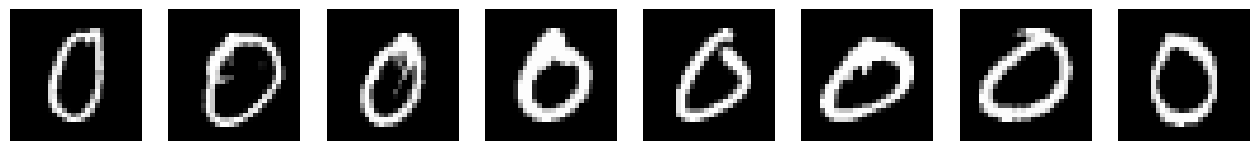

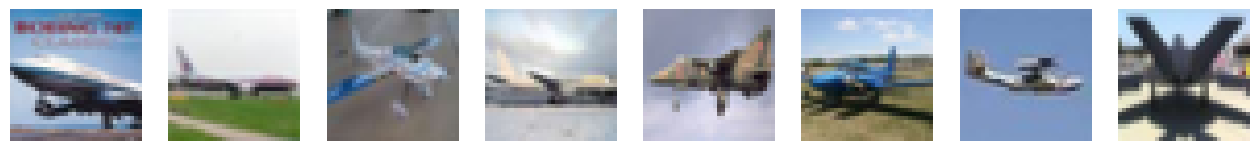

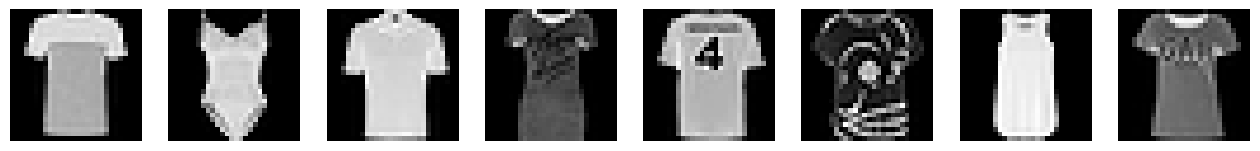

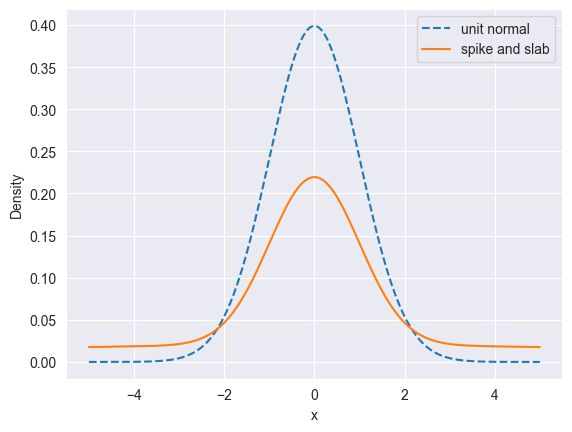

In [20]:
import tensorflow as tf
import tensorflow_probability as tfp
from keras.layers import BatchNormalization, GlobalAveragePooling2D, GlobalMaxPool2D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import RMSprop

import numpy as np
import os
import matplotlib.pyplot as plt

from scipy.interpolate import make_interp_spline
from tensorflow.python.layers.pooling import AveragePooling2D

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

# https://goodboychan.github.io/python/coursera/tensorflow_probability/icl/2021/08/26/01-Bayesian-Convolutional-Neural-Network.html
# https://openaccess.thecvf.com/content_ICCV_2019/papers/Patro_U-CAM_Visual_Explanation_Using_Uncertainty_Based_Class_Activation_Maps_ICCV_2019_paper.pdf






tfd = tfp.distributions
tfpl = tfp.layers


seed = 42

# 2. Set NumPy seed
np.random.seed(seed)

# 3. Set TensorFlow seed
tf.random.set_seed(seed)




def load_mnist():
    (x, y), _ = tf.keras.datasets.mnist.load_data()
    x = ( x / 255.).astype(np.float32)[..., np.newaxis]
    y = y.astype(np.float32)

    return x, y

def load_cifar():
    (x, y), _ = tf.keras.datasets.cifar10.load_data()
    x = (x / 255.).astype(np.float32)
    y = y.astype(np.float32)

    return (x, y)

def load_fashion_mnist():
    (x, y), _ = tf.keras.datasets.fashion_mnist.load_data()
    x = (x / 255.).astype(np.float32)[..., np.newaxis]
    y = y.astype(np.float32)

    return (x, y)

def split_data(x_data, y_data, seed):
  # Step 1: Find unique classes in y_data
  unique_classes = np.unique(y_data)

  # Step 2: Store indices for each class
  class_indices = {cls: np.where(y_data == cls)[0] for cls in unique_classes}

  # Step 3: Split indices into 70% train, 20% val, 10% test
  train_indices = []
  val_indices = []
  test_indices = []

  for cls, indices in class_indices.items():
      # Split class indices into train, val, test (70%, 20%, 10%)
      train, temp = train_test_split(indices, train_size=0.7, random_state=seed)
      val, test = train_test_split(temp, test_size=0.5, random_state=seed)

      train_indices.extend(train)
      val_indices.extend(val)
      test_indices.extend(test)

  # Step 4: Organize x_data and y_data into train, val, test
  x_train = x_data[train_indices]
  y_train = y_data[train_indices]
  x_val = x_data[val_indices]
  y_val = y_data[val_indices]
  x_test = x_data[test_indices]
  y_test = y_data[test_indices]

  # Step 5: Return the datasets
  return (x_train, y_train), (x_val, y_val), (x_test, y_test)

def inspect_images(data, num_images, cmap):
  fig, ax = plt.subplots(nrows=1, ncols=num_images, figsize=(2*num_images, 2))
  for i in range(num_images):
      ax[i].imshow(data[i], cmap = cmap)
      ax[i].axis('off')
  plt.show()

# Load MNIST
x_mnist, y_mnist = load_mnist()

(train_x_mnist, train_y_mnist), (val_x_mnist, val_y_mnist), (test_x_mnist, test_y_mnist) = split_data(x_mnist, y_mnist, seed)
inspect_images(train_x_mnist, 8, 'gray')
mnist_classes = 10

# Load Cifar
x_cifar, y_cifar = load_cifar()
(train_x_cifar, train_y_cifar), (val_x_cifar, val_y_cifar), (test_x_cifar, test_y_cifar) = split_data(x_cifar, y_cifar, seed)

inspect_images(train_x_cifar, 8, None)
cifar_classes = 10

# load fashion mnist
x_fashion, y_fashion = load_fashion_mnist()

(train_x_fashion, train_y_fashion), (val_x_fashion, val_y_fashion), (test_x_fashion, test_y_fashion) = split_data(x_fashion, y_fashion, seed)

inspect_images(train_x_fashion, 8, 'gray')
fashion_classes = 10

# One-hot encode labels
train_y_mnist_oh = tf.keras.utils.to_categorical(train_y_mnist, mnist_classes)
val_y_mnist_oh = tf.keras.utils.to_categorical(val_y_mnist, mnist_classes)

train_y_cifar_oh = tf.keras.utils.to_categorical(train_y_cifar, cifar_classes)
val_y_cifar_oh = tf.keras.utils.to_categorical(val_y_cifar, cifar_classes)

train_y_fashion_oh = tf.keras.utils.to_categorical(train_y_fashion, fashion_classes)
val_y_fashion_oh = tf.keras.utils.to_categorical(val_y_fashion, fashion_classes)

test_y_mnist_oh = tf.keras.utils.to_categorical(test_y_mnist, mnist_classes)
test_y_cifar_oh = tf.keras.utils.to_categorical(test_y_cifar, cifar_classes)
test_y_fashion_oh = tf.keras.utils.to_categorical(test_y_fashion, fashion_classes)

def nll(y_true, y_pred):
    """
    This function should return the negative log-likelihood of each sample
    in y_true given the predicted distribution y_pred. If y_true is of shape
    [B, E] and y_pred has batch shape [B] and event_shape [E], the output
    should be a Tensor of shape [B].
    """

    return -y_pred.log_prob(y_true)

# def get_convolutional_reparameterization_layer(input_shape, divergence_fn):
#     """
#     This function should create an instance of a Convolution2DReparameterization
#     layer according to the above specification.
#     The function takes the input_shape and divergence_fn as arguments, which should
#     be used to define the layer.
#     Your function should then return the layer instance.
#     """
#
#     layer = tfpl.Convolution2DReparameterization(
#         input_shape=input_shape, filters=8, kernel_size=(5, 5),
#         activation='relu', padding='VALID',
#         kernel_prior_fn=tfpl.default_multivariate_normal_fn,
#         kernel_posterior_fn=tfpl.default_mean_field_normal_fn(is_singular=False),
#         kernel_divergence_fn=divergence_fn,
#         bias_prior_fn=tfpl.default_multivariate_normal_fn,
#         bias_posterior_fn=tfpl.default_mean_field_normal_fn(is_singular=False),
#         bias_divergence_fn=divergence_fn
#     )
#     return layer


def get_convolutional_reparameterization_layer(filters, kernel_size, stride, padding, divergence_fn):
     layer = tfpl.Convolution2DReparameterization(
        filters=filters,
        kernel_size=kernel_size,
         strides = stride,
        activation='relu',
        padding=padding,  # Preserves spatial resolution
        kernel_prior_fn=tfpl.default_multivariate_normal_fn,
        kernel_posterior_fn=tfpl.default_mean_field_normal_fn(is_singular=False),
        kernel_divergence_fn=divergence_fn,
        bias_prior_fn=tfpl.default_multivariate_normal_fn,
        bias_posterior_fn=tfpl.default_mean_field_normal_fn(is_singular=False),
        bias_divergence_fn=divergence_fn
    )

     return layer


def spike_and_slab(event_shape, dtype):
    distribution = tfd.Mixture(
        cat=tfd.Categorical(probs=[0.5, 0.5]),
        components=[
            tfd.Independent(tfd.Normal(
                loc=tf.zeros(event_shape, dtype=dtype),
                scale=1.0*tf.ones(event_shape, dtype=dtype)),
                            reinterpreted_batch_ndims=1),
            tfd.Independent(tfd.Normal(
                loc=tf.zeros(event_shape, dtype=dtype),
                scale=10.0*tf.ones(event_shape, dtype=dtype)),
                            reinterpreted_batch_ndims=1)],
    name='spike_and_slab')
    return distribution

x_plot = np.linspace(-5, 5, 1000)[:, np.newaxis]
plt.plot(x_plot, tfd.Normal(loc=0, scale=1).prob(x_plot).numpy(), label='unit normal', linestyle='--')
plt.plot(x_plot, spike_and_slab(1, dtype=tf.float32).prob(x_plot).numpy(), label='spike and slab')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()

def get_prior(kernel_size, bias_size, dtype=None):
    """
    This function should create the prior distribution, consisting of the
    "spike and slab" distribution that is described above.
    The distribution should be created using the kernel_size, bias_size and dtype
    function arguments above.
    The function should then return a callable, that returns the prior distribution.
    """
    n = kernel_size+bias_size
    prior_model = Sequential([tfpl.DistributionLambda(lambda t : spike_and_slab(n, dtype))])
    return prior_model

def get_posterior(kernel_size, bias_size, dtype=None):
    """
    This function should create the posterior distribution as specified above.
    The distribution should be created using the kernel_size, bias_size and dtype
    function arguments above.
    The function should then return a callable, that returns the posterior distribution.
    """
    n = kernel_size + bias_size
    return Sequential([
        tfpl.VariableLayer(tfpl.IndependentNormal.params_size(n), dtype=dtype),
        tfpl.IndependentNormal(n)
    ])

def get_dense_variational_layer(units, prior_fn, posterior_fn, kl_weight):
    """
    This function should create an instance of a DenseVariational layer according
    to the above specification.
    The function takes the prior_fn, posterior_fn and kl_weight as arguments, which should
    be used to define the layer.
    Your function should then return the layer instance.
    """
    return tfpl.DenseVariational(
        units=units, make_posterior_fn=posterior_fn, make_prior_fn=prior_fn, kl_weight=kl_weight
    )




# convolutional_reparameterization_layer = get_convolutional_reparameterization_layer(
#     input_shape=(28, 28, 1), divergence_fn=divergence_fn
# )

# convolutional_reparameterization_layer = get_convolutional_reparameterization_layer(
#     filters=(8,8),
#     kernel_size=(1, 1),
#     divergence_fn=divergence_fn)




from tensorflow.keras.layers import InputLayer

def build_model(shape, num_classes, train_size):
    divergence_fn = lambda q, p, _: tfd.kl_divergence(q, p) / train_size

    dense_variational_layer = get_dense_variational_layer(num_classes,
        get_prior, get_posterior, kl_weight=1 / train_size
    )

    model = Sequential([
        InputLayer(input_shape=shape),

        # Conv Block 1
        get_convolutional_reparameterization_layer(filters=32, kernel_size=(3, 3), stride=(1,1), padding='SAME', divergence_fn=divergence_fn),
        BatchNormalization(),
        get_convolutional_reparameterization_layer(filters=32, kernel_size=(3, 3), stride=(1,1), padding='SAME', divergence_fn=divergence_fn),
        BatchNormalization(),
        AveragePooling2D(pool_size=(2,2), strides=(2,2)),

        # Conv Block 2
        get_convolutional_reparameterization_layer(filters=64, kernel_size=(3, 3), stride=(1,1), padding='SAME', divergence_fn=divergence_fn),
        BatchNormalization(),
        get_convolutional_reparameterization_layer(filters=64, kernel_size=(3, 3), stride=(1,1), padding='SAME', divergence_fn=divergence_fn),
        BatchNormalization(),

        # Conv Block 3
        get_convolutional_reparameterization_layer(filters=128, kernel_size=(3, 3), stride=(1,1), padding='SAME', divergence_fn=divergence_fn),
        BatchNormalization(),
        get_convolutional_reparameterization_layer(filters=128, kernel_size=(3, 3), stride=(1,1), padding='SAME', divergence_fn=divergence_fn),
        BatchNormalization(),
        AveragePooling2D(pool_size=(2,2), strides=(2,2)),

        # Conv Block 4
        get_convolutional_reparameterization_layer(filters=256, kernel_size=(3, 3), stride=(1,1), padding='SAME', divergence_fn=divergence_fn),
        BatchNormalization(),
        get_convolutional_reparameterization_layer(filters=256, kernel_size=(3, 3), stride=(1,1), padding='SAME', divergence_fn=divergence_fn),
        BatchNormalization(),

        # GAP + Dense Head
        GlobalAveragePooling2D(),
        dense_variational_layer,
        tfp.layers.OneHotCategorical(num_classes, convert_to_tensor_fn=tfd.Distribution.mode)
    ])

    return model



Specify the model weights path

In [29]:
print("Select a dataset:")
print("1 - MNIST")
print("2 - Fashion MNIST")
print("3 - CIFAR-10")

dataset_option = int(input("Enter the number corresponding to your choice: "))


# Default fallbacks
shape = (28, 28, 1)
num_classes = 10
class_names = []
model_weights_path = ""
train_x = val_x = test_x = None
train_y = val_y = test_y = None
train_y_oh = val_y_oh = test_y_oh = None

if dataset_option == 1:
    shape = (28, 28, 1)
    class_names = [str(i) for i in range(10)]
    dataset_name = "MNIST"
    model_weights_path = "weights/bcnn_mnist_best_weights.h5"

    train_x = train_x_mnist
    val_x = val_x_mnist
    test_x = test_x_mnist

    train_y = train_y_mnist
    val_y = val_y_mnist
    test_y = test_y_mnist

    train_y_oh = train_y_mnist_oh
    val_y_oh = val_y_mnist_oh
    test_y_oh = test_y_mnist_oh

elif dataset_option == 2:
    shape = (28, 28, 1)
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    dataset_name = "Fashion MNIST"
    model_weights_path = "weights/bcnn_fashion_best_weights.h5"

    train_x = train_x_fashion
    val_x = val_x_fashion
    test_x = test_x_fashion

    train_y = train_y_fashion
    val_y = val_y_fashion
    test_y = test_y_fashion

    train_y_oh = train_y_fashion_oh
    val_y_oh = val_y_fashion_oh
    test_y_oh = test_y_fashion_oh

elif dataset_option == 3:
    shape = (32, 32, 3)
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
    dataset_name = "CIFAR-10"
    model_weights_path = "weights/bcnn_cifar_best_weights.h5"

    train_x = train_x_cifar
    val_x = val_x_cifar
    test_x = test_x_cifar

    train_y = train_y_cifar
    val_y = val_y_cifar
    test_y = test_y_cifar

    train_y_oh = train_y_cifar_oh
    val_y_oh = val_y_cifar_oh
    test_y_oh = test_y_cifar_oh

else:
    raise ValueError("Invalid option selected. Choose 1, 2, or 3.")

# Summary
print(f"\n✅ Dataset Selected: {dataset_name}")
print(f"Input Shape: {shape}")
print(f"Number of Classes: {num_classes}")
print(f"Class Names: {class_names}")
print(f"Train Size: {len(train_x)}")
print(f"Validation Size: {len(val_x)}")
print(f"Test Size: {len(test_x)}")
print(f"Model Weights Path: {model_weights_path}")

# Example usage:
model = build_model(shape, num_classes, len(train_x))
model.load_weights(model_weights_path)


Select a dataset:
1 - MNIST
2 - Fashion MNIST
3 - CIFAR-10

✅ Dataset Selected: CIFAR-10
Input Shape: (32, 32, 3)
Number of Classes: 10
Class Names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train Size: 35000
Validation Size: 7500
Test Size: 7500
Model Weights Path: weights/bcnn_cifar_best_weights.h5


Last Conv2D layer found: conv2d_reparameterization_63


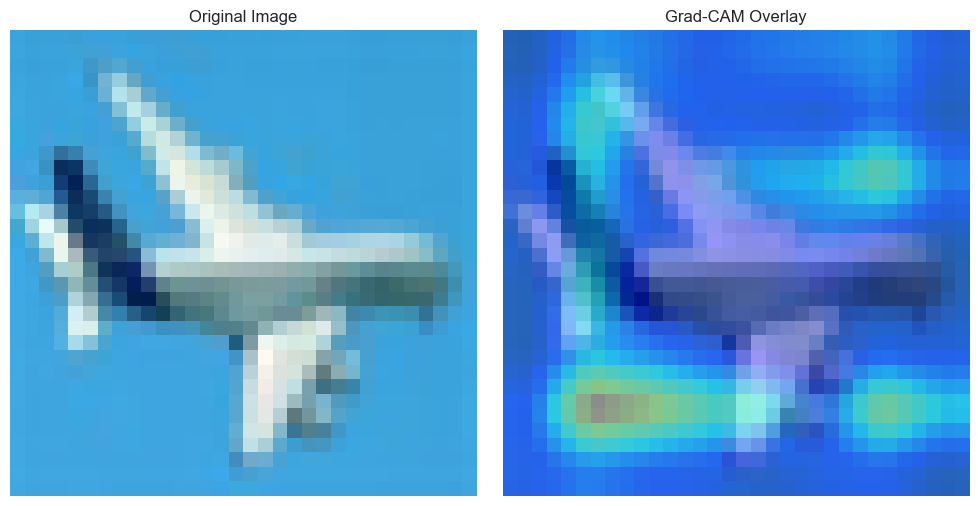

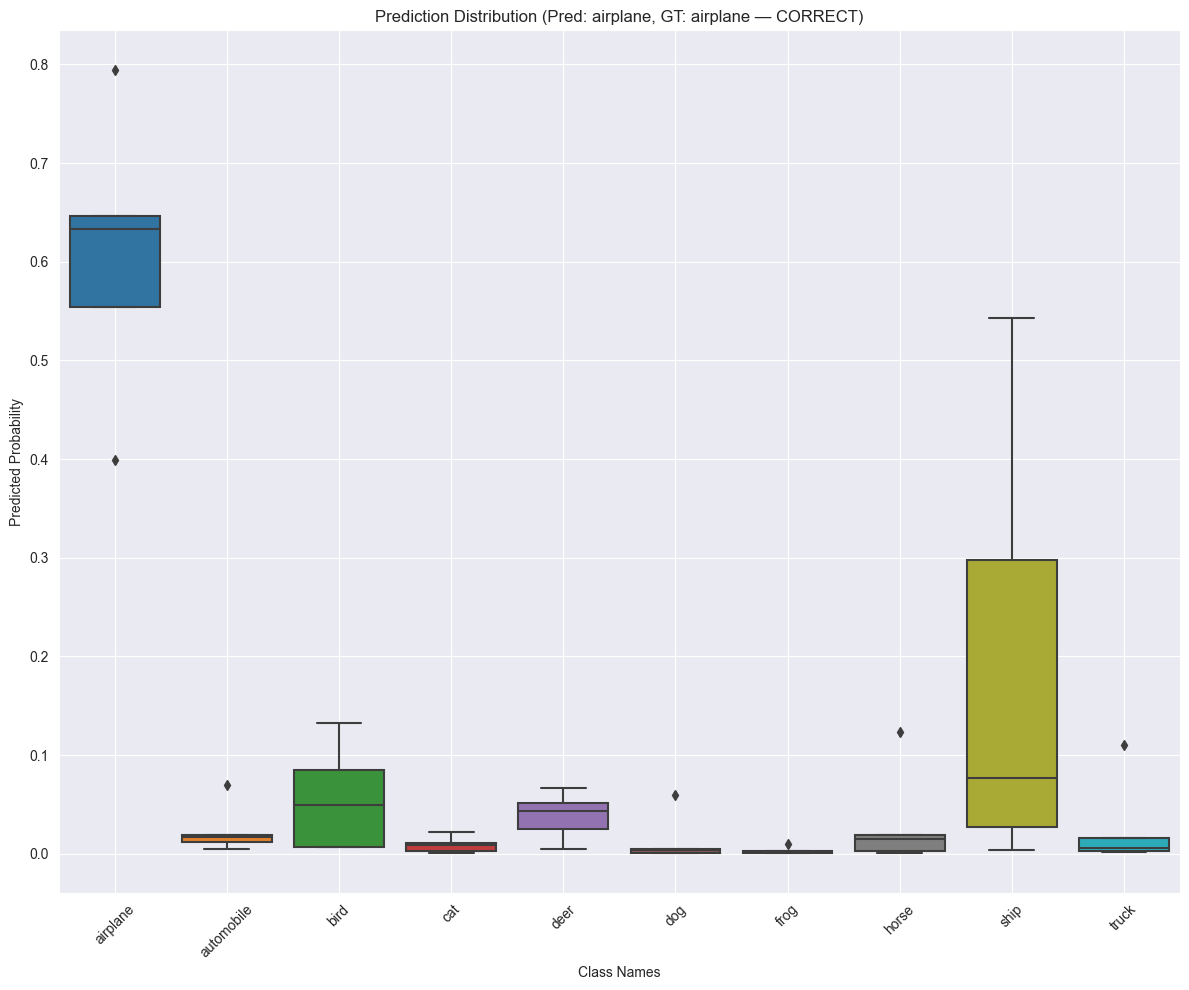

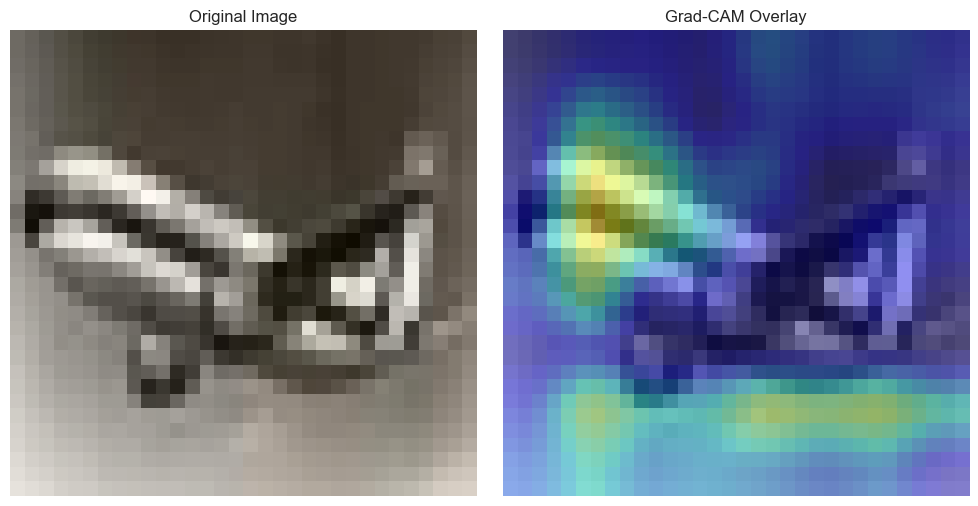

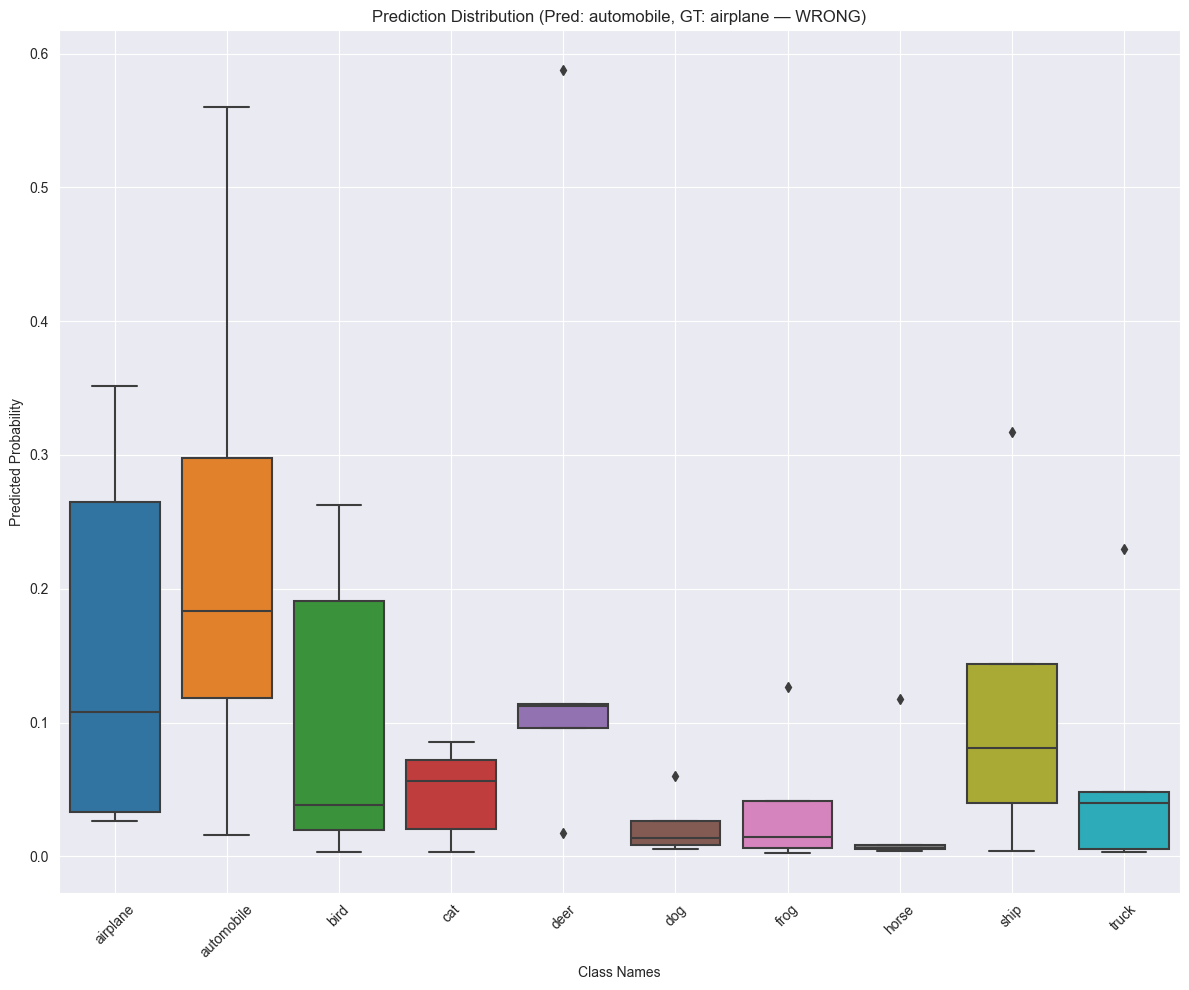

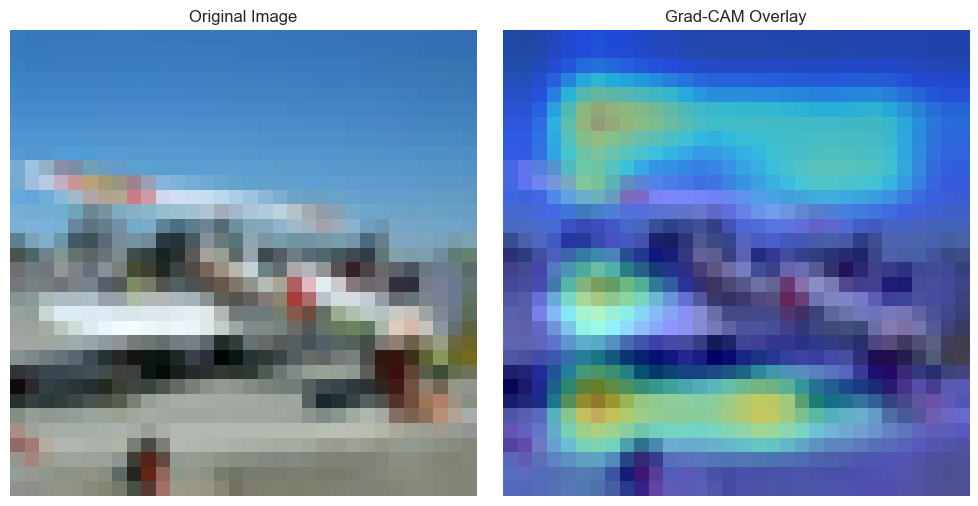

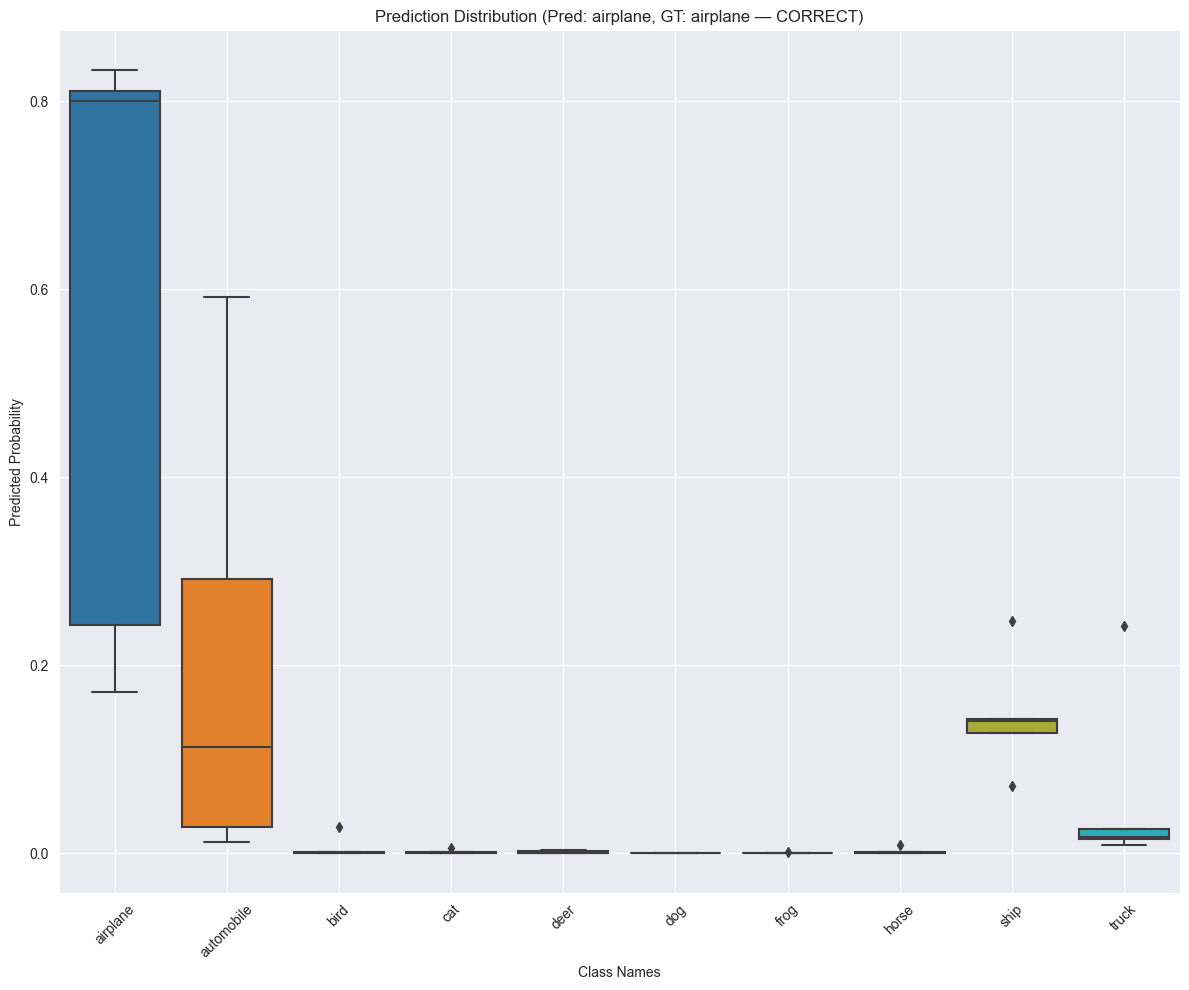

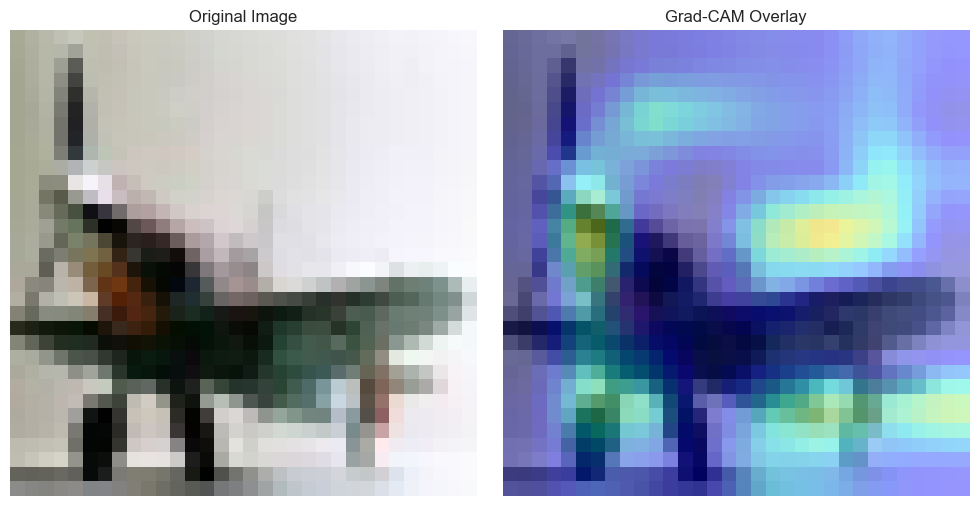

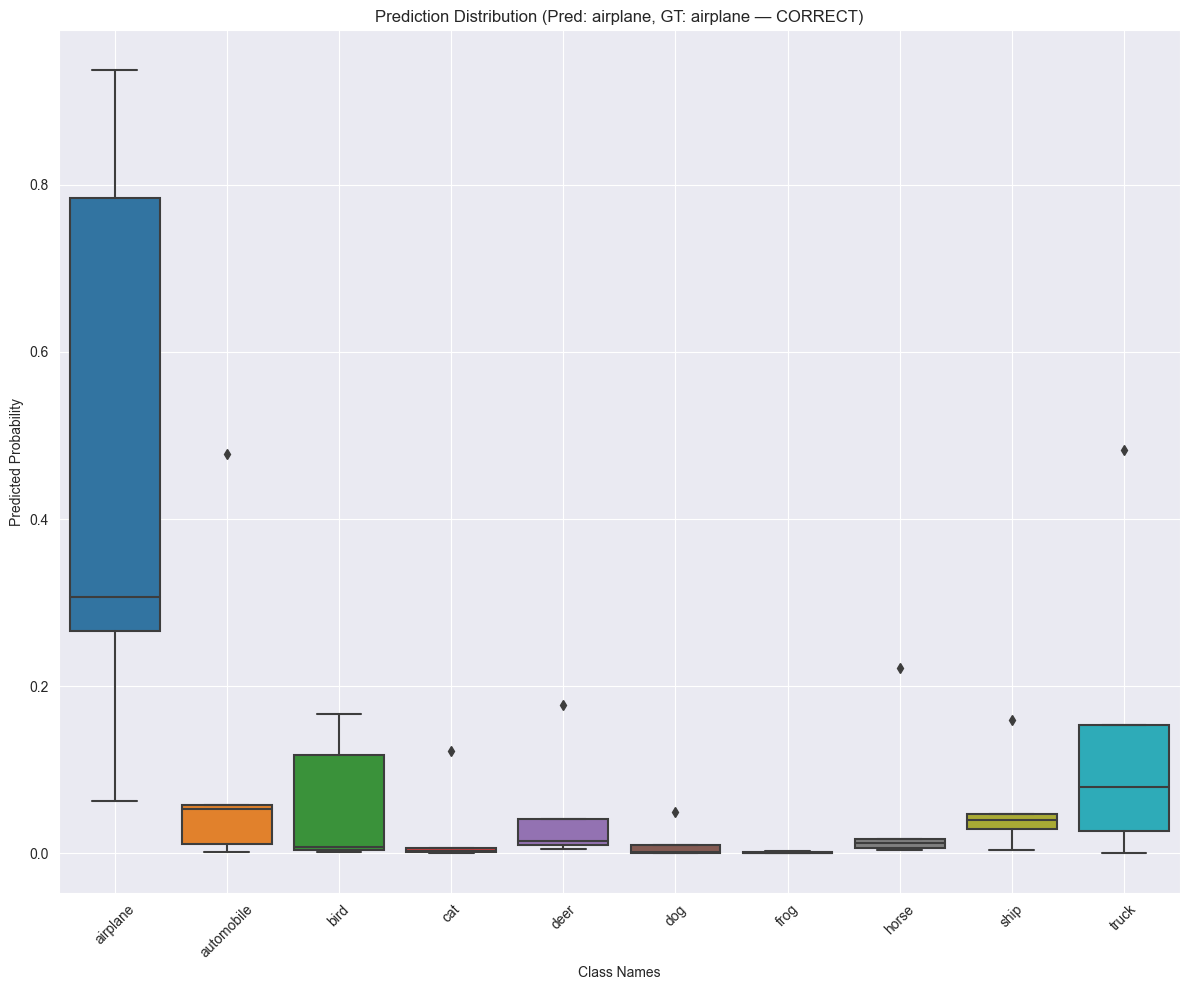

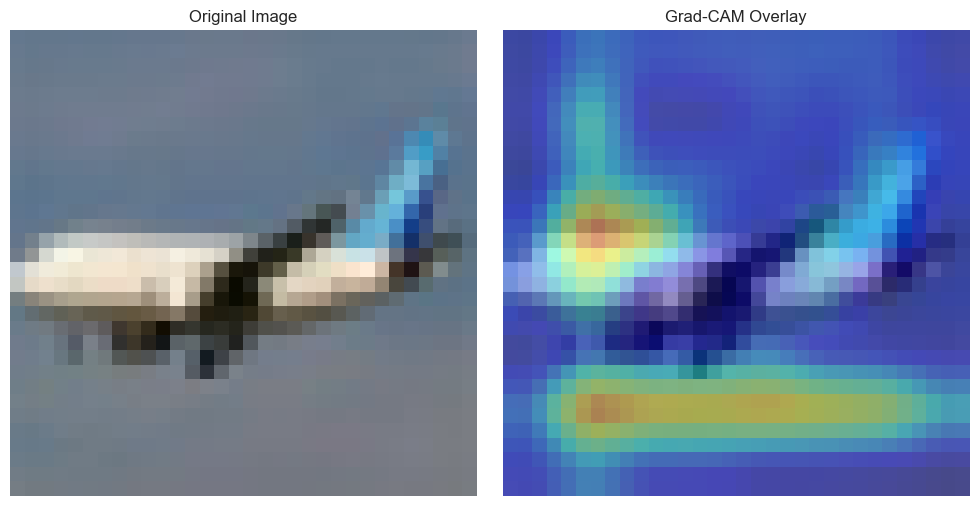

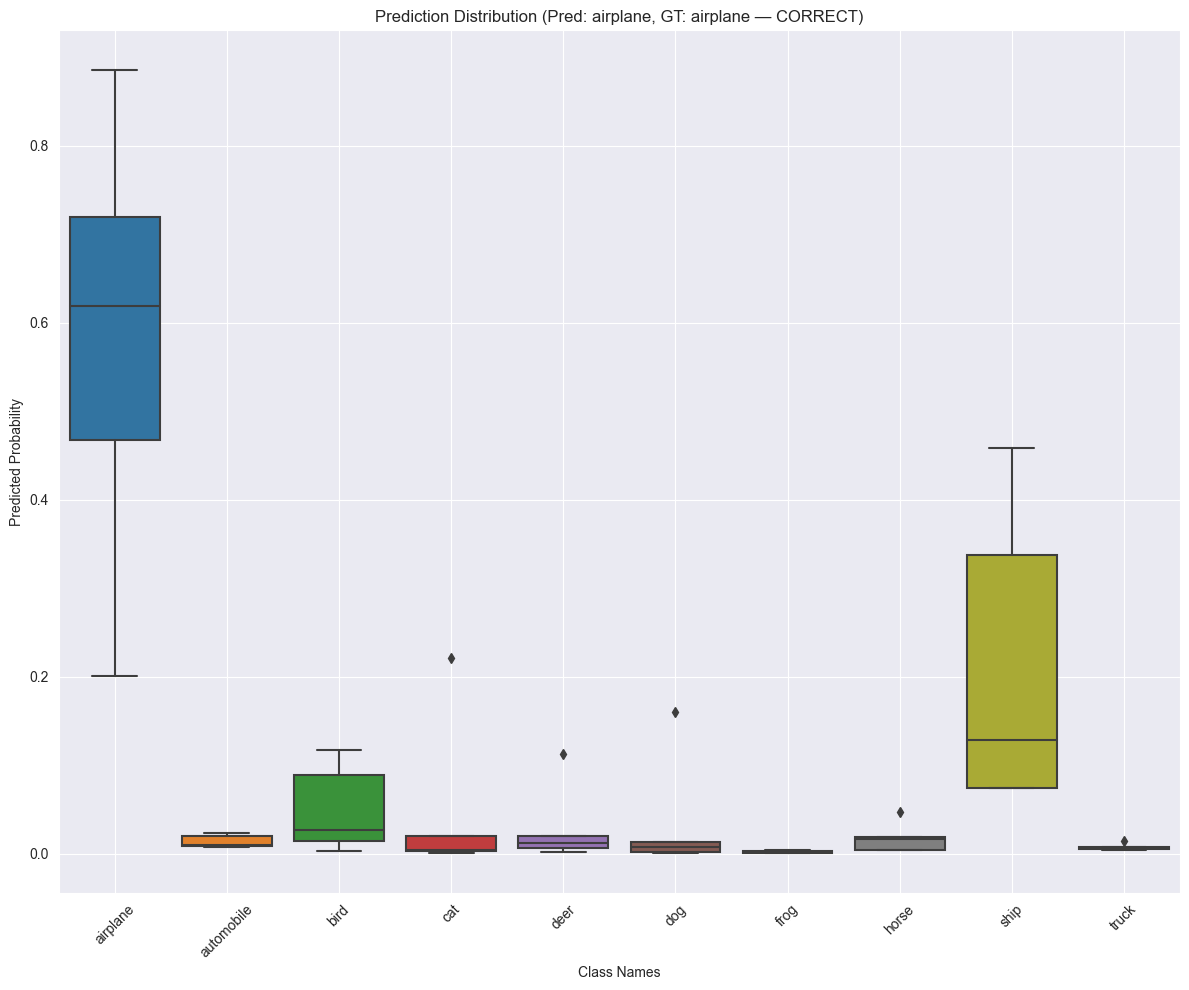

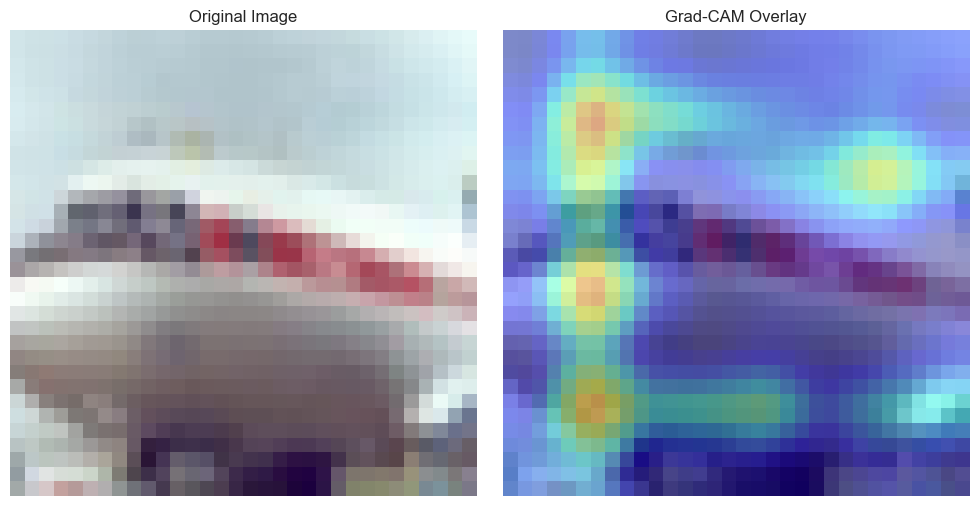

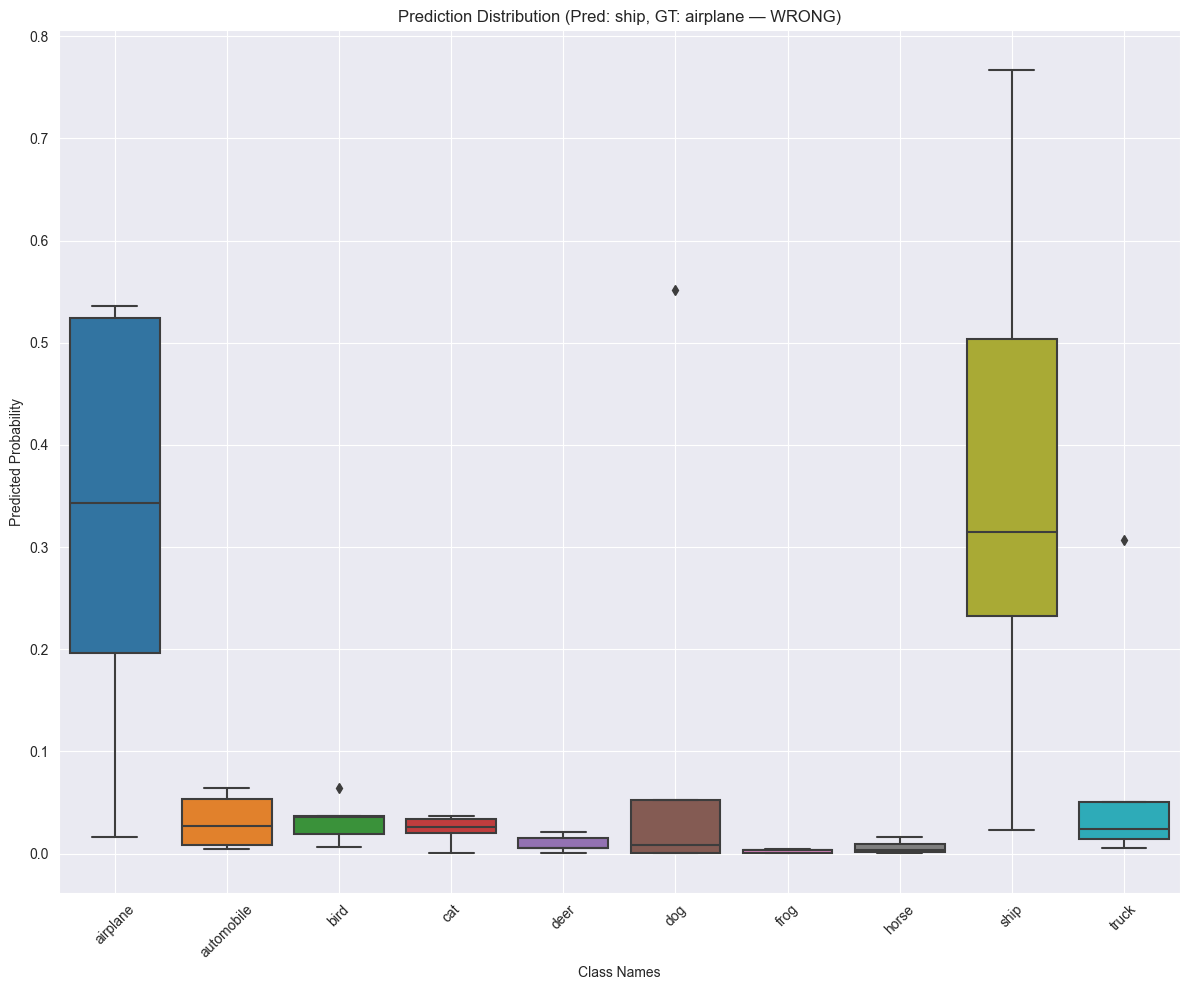

In [56]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

test_indices = [0,2,3,10,25,100]
number_of_passes = 5
cmap = 'jet'
alpha = 0.4

# Assume 'model' is your Keras model

# Find last Conv2D layer name
target_layer_name = None
for layer in reversed(model.layers):
    if 'conv2d' in layer.name.lower():
        target_layer_name = layer.name
        break

print("Last Conv2D layer found:", target_layer_name)

# Get the layer object
target_layer = model.get_layer(target_layer_name)

def compute_gradcam_and_preds(model, image, class_index, target_layer):
    image = tf.convert_to_tensor(image[np.newaxis, ...])

    grad_model = tf.keras.models.Model(
        [model.input],
        [target_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        if isinstance(predictions, tfp.distributions.Distribution):
            predictions = predictions.mean()
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap + 1e-8)

    return heatmap.numpy(), predictions.numpy()[0]

def monte_carlo_gradcam_and_preds(model, image, class_index, target_layer, num_passes):
    heatmaps = []
    preds = []

    for _ in range(num_passes):
        heatmap, pred = compute_gradcam_and_preds(model, image, class_index, target_layer)
        heatmaps.append(heatmap)
        preds.append(pred)

    heatmaps = np.array(heatmaps)
    preds = np.array(preds)  # shape: (num_passes, num_classes)

    avg_heatmap = np.mean(heatmaps, axis=0)
    return avg_heatmap, preds

# -----------------------
# Visualization Utilities
# -----------------------
def ensure_rgb(img):
    """Ensure image is 3-channel RGB."""
    if img.ndim == 2:  # shape: (H, W)
        img = np.stack([img]*3, axis=-1)
    elif img.shape[-1] == 1:  # shape: (H, W, 1)
        img = np.repeat(img, 3, axis=-1)
    return img

def to_uint8(image):
    """Convert float or normalized image to uint8 [0, 255]"""
    if image.dtype != np.uint8:
        image = image - image.min()
        image = image / (image.max() + 1e-8)
        image = (image * 255).astype(np.uint8)
    return image

# -----------------------
# Visualization
# -----------------------

for index_from_test in test_indices:
    image = test_x[index_from_test]
    label = test_y_oh[index_from_test]
    class_index = np.argmax(label)

    avg_heatmap, preds = monte_carlo_gradcam_and_preds(
        model, image, class_index, target_layer, number_of_passes
    )

    image_rgb = ensure_rgb(image)
    image_rgb = to_uint8(image_rgb)

    heatmap_resized = cv2.resize(avg_heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cm.get_cmap(cmap)(heatmap_resized)[..., :3]
    heatmap_colored = (255 * heatmap_colored).astype(np.uint8)

    overlayed_image = cv2.addWeighted(image_rgb, 1 - alpha, heatmap_colored, alpha, 0)

    # Plot: Original + Overlay
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(overlayed_image)
    plt.title("Grad-CAM Overlay")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

    mean_preds = preds.mean(axis=0)
    predicted_class = np.argmax(mean_preds)
    status = "CORRECT" if predicted_class == class_index else "WRONG"

    # Plot prediction distribution
    plt.figure(figsize=(12, 10))
    sns.boxplot(data=preds)
    plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45)
    plt.title(
        f"Prediction Distribution (Pred: {class_names[predicted_class]}, "
        f"GT: {class_names[class_index]} — {status})"
    )
    plt.xlabel("Class Names")
    plt.ylabel("Predicted Probability")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

